In [1]:
import socket
print(socket.gethostname())

awr-2-15


In [2]:
import warnings

import xarray as xr
import hdf5plugin
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
from scipy.interpolate import interp1d

In [3]:
from dask.distributed import Client
client = Client(n_workers=8, threads_per_worker=4)

print(client.dashboard_link)
print(client)

http://127.0.0.1:8787/status
<Client: 'tcp://127.0.0.1:35301' processes=8 threads=32, memory=64.00 GiB>


In [3]:
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=xr.SerializationWarning)
    dsp = xr.open_mfdataset('/cw3e/mead/projects/cwp167/moerfani_data/regional/2019/01P/wwrf_reanalysis_modellev_d01_2019-01-01*.nc', engine='h5netcdf', data_vars='all')
    dss = xr.open_mfdataset('/cw3e/mead/projects/cwp167/moerfani_data/regional/2019/01S/wwrf_reanalysis_singlelev_d01_2019-01-01*.nc', engine='h5netcdf', data_vars='all')

We will extract the pressure variables and single level variables from all 24 nc files representing one day as follows. These variables will then be resampled to 6-hour intervals and stored in a new netcdf file. For the precipitation variable, this resampling should be different (e.g., accumulation over the period).

**Pressure variables:**
- Geopotential (Z_e)
- Temperature (T_e)
- Specific humidity (q_e)
- Zonal wind (u_gr_e)
- Meridional wind (v_gr_e)
- Pressure (p_e)

**Single levels:**
- Mean sea level pressure (slp)
- Surface pressure (p_sfc)
- 2-m dewpoint temperature (Td_2m)
- 2-m temperature (T_2m)
- Skin/sea surface temperature (T_sfc)
- Integrated water vapor (IWV)
- Integrated vapor transport (meridional) (IVTV)
- Integrated vapor transport (zonal) (IVTU)
- 10-m zonal wind (u_10m_gr)
- 10-m meridional wind (v_10m_gr)
- 6-hourly accumulated precipitation (precip_bkt)

**Forcing:**
- Geopotential at the surface (Z_sfc)

In [4]:
# Extract pressure variables from dsp
pressure_vars = ['Z_e', 'T_e', 'q_e', 'u_gr_e', 'v_gr_e', 'p_e']
dsp_selected = dsp[pressure_vars]

# Extract single level and forcing variables from dss
single_vars = ['slp', 'p_sfc', 'Td_2m', 'T_2m', 'T_sfc', 'IWV', 'IVTV', 'IVTU', 'u_10m_gr', 'v_10m_gr', 'precip_bkt', 'Z_sfc']
dss_selected = dss[single_vars]

# Merge the datasets
ds_combined = xr.merge([dsp_selected, dss_selected], compat='override')

# Resample to 6-hour intervals
# For precipitation, use sum (accumulation over the period)
precip_resampled = ds_combined['precip_bkt'].resample(time='6h').sum()

# For other variables, use mean
others = ds_combined.drop_vars('precip_bkt')
others_resampled = others.resample(time='6h').mean()

# Merge back the resampled data
ds_resampled = xr.merge([others_resampled, precip_resampled], compat='override')

# Save to a new NetCDF file
save_path = '/cw3e/mead/projects/cwp167/moerfani_data/regional/2019/01M/wwrf_reanalysis_modellev_d01_2019-01-01-v2.nc'
ds_resampled.to_netcdf(save_path)

/scratch/moerfani/job_3281964/ipykernel_3950528/471911674.py:10: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_combined = xr.merge([dsp_selected, dss_selected])
/scratch/moerfani/job_3281964/ipykernel_3950528/471911674.py:10: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_combined = xr.merge([dsp_selected, dss_selected])


In [4]:
save_path = '/cw3e/mead/projects/cwp167/moerfani_data/regional/2019/01M/wwrf_reanalysis_modellev_d01_2019-01-01-v2.nc'
ds_resampled = xr.open_mfdataset(save_path, engine='h5netcdf', data_vars='all')
ds_resampled

<xarray.Dataset> Size: 13GB
Dimensions:      (time: 4, eta: 99, south_north: 970, west_east: 1389)
Coordinates:
  * time         (time) datetime64[ns] 32B 2019-01-01 ... 2019-01-01T18:00:00
  * eta          (eta) float32 396B 0.998 0.9932 0.9873 ... 0.001282 0.0004168
  * south_north  (south_north) float32 4kB -2.827e+03 -2.821e+03 ... 2.988e+03
  * west_east    (west_east) float32 6kB -5.238e+03 -5.232e+03 ... 3.091e+03
    lat          (south_north, west_east) float32 5MB dask.array<chunksize=(970, 1389), meta=np.ndarray>
    lon          (south_north, west_east) float32 5MB dask.array<chunksize=(970, 1389), meta=np.ndarray>
Data variables: (12/18)
    Z_e          (time, eta, south_north, west_east) float32 2GB dask.array<chunksize=(4, 99, 970, 1389), meta=np.ndarray>
    T_e          (time, eta, south_north, west_east) float32 2GB dask.array<chunksize=(4, 99, 970, 1389), meta=np.ndarray>
    q_e          (time, eta, south_north, west_east) float32 2GB dask.array<chunksize=(4, 99, 970, 1389), meta=np.ndarray>
    u_gr_e       (time, eta, south_north, west_east) float32 2GB dask.array<chunksize=(4, 99, 970, 1389), meta=np.ndarray>
    v_gr_e       (time, eta, south_north, west_east) float32 2GB dask.array<chunksize=(4, 99, 970, 1389), meta=np.ndarray>
    p_e          (time, eta, south_north, west_east) float32 2GB dask.array<chunksize=(4, 99, 970, 1389), meta=np.ndarray>
    ...           ...
    IVTV         (time, south_north, west_east) float32 22MB dask.array<chunksize=(4, 970, 1389), meta=np.ndarray>
    IVTU         (time, south_north, west_east) float32 22MB dask.array<chunksize=(4, 970, 1389), meta=np.ndarray>
    u_10m_gr     (time, south_north, west_east) float32 22MB dask.array<chunksize=(4, 970, 1389), meta=np.ndarray>
    v_10m_gr     (time, south_north, west_east) float32 22MB dask.array<chunksize=(4, 970, 1389), meta=np.ndarray>
    Z_sfc        (time, south_north, west_east) float32 22MB dask.array<chunksize=(4, 970, 1389), meta=np.ndarray>
    precip_bkt   (time, south_north, west_east) float32 22MB dask.array<chunksize=(4, 970, 1389), meta=np.ndarray>
Attributes:
    CDI:            Climate Data Interface version 2.4.4 (https://mpimet.mpg....
    Conventions:    CF 1.6, Standard Name Table v19
    source:         /cw3e/mead/projects/cnt117/reanalysis_temp/input/2018/d01...
    institution:    CW3E - Scripps Institution of Oceanography
    title:          /cw3e/mead/projects/cnt117/reanalysis_temp/output/2018/d0...
    notes:          Created with NCL script:  wrfout_to_cf.ncl v2.0
    created_by:     Daniel Steinhoff - dsteinhoff@ucsd.edu
    creation_date:  Fri Dec  5 01:18:13 PM PST 2025
    history:        Fri Dec  5 13:24:15 2025: /home/cw3eprod/miniforge3/envs/...
    CDO:            Climate Data Operators version 2.4.4 (https://mpimet.mpg....
    NCO:            netCDF Operators version 5.2.9 (Homepage = http://nco.sf....

To map your specific pressure levels to the provided eta ($\eta$) levels, we can calculate the closest mathematical match based on how terrain-following coordinates work.

Generally, the eta coordinate is defined as:
$\eta = \frac{p - p_t}{p_s - p_t}$

Where $p$ is the pressure at a given level, $p_s$ is the surface pressure, and $p_t$ is the model top pressure. If we assume a standard nominal surface pressure of **1013.25 hPa** and a top-of-atmosphere pressure of **0 hPa**, the target eta values simply become a fraction of the surface pressure ($p \approx \eta \times 1013.25$).

### The Nominal Mapping

By dividing your target pressure levels by 1013.25, we get the target $\eta$ values (e.g., 500 hPa becomes $\eta = 0.49346$). Finding the nearest neighbor in your provided array gives us this exact correspondence:

| Target Pressure (hPa) | Target $\eta$ | Closest Array $\eta$ | Array Index (0-indexed) | Nominal Pressure (hPa) |
| --- | --- | --- | --- | --- |
| **1000** | 0.98692 | 0.987305 | **2** | 1000.39 |
| **925** | 0.91290 | 0.916016 | **12** | 928.15 |
| **850** | 0.83888 | 0.840820 | **19** | 851.96 |
| **700** | 0.69084 | 0.690430 | **29** | 699.58 |
| **600** | 0.59215 | 0.600586 | **34** | 608.54 |
| **500** | 0.49346 | 0.486328 | **40** | 492.77 |
| **400** | 0.39477 | 0.392578 | **45** | 397.78 |
| **300** | 0.29609 | 0.291016 | **51** | 294.87 |
| **250** | 0.24673 | 0.246094 | **54** | 249.35 |
| **200** | 0.19738 | 0.193359 | **58** | 195.92 |
| **150** | 0.14804 | 0.149414 | **62** | 151.39 |
| **100** | 0.09869 | 0.097534 | **68** | 98.83 |
| **50** | 0.04935 | 0.049927 | **76** | 50.59 |

In [2]:
import numpy as np

# Your provided array of 99 eta levels
eta_levels = np.array([
    9.9804688e-01, 9.9316406e-01, 9.8730469e-01, 9.8242188e-01,
    9.7656250e-01, 9.6972656e-01, 9.6386719e-01, 9.5703125e-01,
    9.4921875e-01, 9.4140625e-01, 9.3359375e-01, 9.2480469e-01,
    9.1601562e-01, 9.0722656e-01, 8.9746094e-01, 8.8671875e-01,
    8.7597656e-01, 8.6425781e-01, 8.5253906e-01, 8.4082031e-01,
    8.2812500e-01, 8.1445312e-01, 8.0078125e-01, 7.8613281e-01,
    7.7148438e-01, 7.5585938e-01, 7.4023438e-01, 7.2460938e-01,
    7.0800781e-01, 6.9042969e-01, 6.7285156e-01, 6.5527344e-01,
    6.3769531e-01, 6.1914062e-01, 6.0058594e-01, 5.8203125e-01,
    5.6250000e-01, 5.4394531e-01, 5.2441406e-01, 5.0585938e-01,
    4.8632812e-01, 4.6777344e-01, 4.4824219e-01, 4.2968750e-01,
    4.1113281e-01, 3.9257812e-01, 3.7500000e-01, 3.5742188e-01,
    3.3984375e-01, 3.2324219e-01, 3.0664062e-01, 2.9101562e-01,
    2.7539062e-01, 2.6074219e-01, 2.4609375e-01, 2.3242188e-01,
    2.1875000e-01, 2.0605469e-01, 1.9335938e-01, 1.8164062e-01,
    1.7089844e-01, 1.6015625e-01, 1.4941406e-01, 1.3964844e-01,
    1.3085938e-01, 1.2207031e-01, 1.1328125e-01, 1.0546875e-01,
    9.7534180e-02, 9.0332031e-02, 8.3557129e-02, 7.7087402e-02,
    7.0983887e-02, 6.5246582e-02, 5.9875488e-02, 5.4748535e-02,
    4.9926758e-02, 4.5471191e-02, 4.1259766e-02, 3.7353516e-02,
    3.3691406e-02, 3.0395508e-02, 2.7282715e-02, 2.4414062e-02,
    2.1789551e-02, 1.9348145e-02, 1.7150879e-02, 1.5075684e-02,
    1.3122559e-02, 1.1352539e-02, 9.7274780e-03, 8.2168579e-03,
    6.8206787e-03, 5.5313110e-03, 4.3411255e-03, 3.2424927e-03,
    2.2201538e-03, 1.2817383e-03, 4.1675568e-04
])

# The exact target levels from the manuscript excerpt
target_pressures_hpa = np.array([50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000])

# Use the study's exact reference surface pressure assumption (1013.25 hPa)
# P_target / 1013.25 = Eta_target
target_etas = target_pressures_hpa / 1013.25

# Find the index of the nearest eta value for each target
nearest_indices = [np.abs(eta_levels - target).argmin() for target in target_etas]
matched_etas = eta_levels[nearest_indices]

# Print the correspondence mapping
print("Index Selection Based on 1013.25 hPa Reference Pressure:\n")
for p, eta, idx in zip(target_pressures_hpa, matched_etas, nearest_indices):
    nominal_p = eta * 1013.25
    print(f"Target: {p:>4} hPa -> Extract Index: {idx:>2} | (Eta: {eta:.6f}, Nominal P: {nominal_p:.2f} hPa)")

Index Selection Based on 1013.25 hPa Reference Pressure:

Target:   50 hPa -> Extract Index: 76 | (Eta: 0.049927, Nominal P: 50.59 hPa)
Target:  100 hPa -> Extract Index: 68 | (Eta: 0.097534, Nominal P: 98.83 hPa)
Target:  150 hPa -> Extract Index: 62 | (Eta: 0.149414, Nominal P: 151.39 hPa)
Target:  200 hPa -> Extract Index: 58 | (Eta: 0.193359, Nominal P: 195.92 hPa)
Target:  250 hPa -> Extract Index: 54 | (Eta: 0.246094, Nominal P: 249.35 hPa)
Target:  300 hPa -> Extract Index: 51 | (Eta: 0.291016, Nominal P: 294.87 hPa)
Target:  400 hPa -> Extract Index: 45 | (Eta: 0.392578, Nominal P: 397.78 hPa)
Target:  500 hPa -> Extract Index: 40 | (Eta: 0.486328, Nominal P: 492.77 hPa)
Target:  600 hPa -> Extract Index: 34 | (Eta: 0.600586, Nominal P: 608.54 hPa)
Target:  700 hPa -> Extract Index: 29 | (Eta: 0.690430, Nominal P: 699.58 hPa)
Target:  850 hPa -> Extract Index: 19 | (Eta: 0.840820, Nominal P: 851.96 hPa)
Target:  925 hPa -> Extract Index: 12 | (Eta: 0.916016, Nominal P: 928.15 h

In [ ]:
ds_resampled_subset = ds_resampled.isel(eta=nearest_indices)

### Conversion of Eta coordinate into hybdrid Sigma-pressure coordinate system

### Step 1: Calculate the 3D Pressure Field for WRF
WRF’s eta coordinate ($\eta$) is a mass-based terrain-following coordinate. To do the vertical interpolation, you first need the actual physical pressure at every 3D grid point in your WRF output. 
In standard WRF output, the total pressure is the sum of the base state pressure and the perturbation pressure:
$$P_{WRF}(x,y,z) = \text{PB}(x,y,z) + \text{P}(x,y,z)$$

### Step 2: Define the Target ERA5 3D Pressure Field on the WRF Grid
ERA5 uses a hybrid sigma-pressure coordinate system, where the pressure at any given level $k$ is determined by predefined coefficients ($a_k$ and $b_k$) and the surface pressure:
$$P_{ERA5}(x,y,k) = a_k + b_k \cdot P_{sfc}(x,y)$$

Because you want to keep your data at the **6km WRF horizontal resolution**, you must calculate this target pressure field using the $a_k$ and $b_k$ coefficients from ERA5 (available in the ECMWF documentation), but using the **WRF surface pressure** (`PSFC`) at 6km. This gives you a 3D target pressure field that has 137 vertical levels but is perfectly aligned with your 6km WRF horizontal grid.

### Step 3: Perform 1D Vertical Interpolation
Now that you have the source pressure ($P_{WRF}$) and the target pressure ($P_{ERA5}$) for every single grid column $(x,y)$, you can interpolate your variables (temperature, wind, etc.) vertically. 

For every horizontal point $(x,y)$:
* **Source X:** $P_{WRF}$ (99 levels)
* **Source Y:** Variable to interpolate (e.g., Temperature, 99 levels)
* **Target X:** $P_{ERA5}$ (137 levels)

*Note: For wind components or variables on staggered grids in WRF, make sure to destagger them to the mass points before doing the vertical interpolation.*

### Step 4: Handle Extrapolation (Crucial)
You will likely encounter situations where the lowest ERA5 level is below the lowest WRF level, or the ERA5 model top is higher than the WRF model top. You must decide how to handle these bounds:
* **Near the surface:** Extrapolating variables like temperature below the ground often requires specific atmospheric lapse rate calculations rather than simple linear extrapolation. 
* **Near the top:** If ERA5 goes up to 0.01 hPa and your WRF run only goes to 10 hPa, you cannot safely extrapolate data up to the mesosphere. It is usually best to mask these upper levels as missing data (`NaN`).

In [6]:
df = pd.read_csv('ecmwf_coeffs.csv')
df.head()

,level_number,alpha,beta,half_level_pressure,full_level_pressure,geopotential_altitude,geometric_altitude,temperature,density
0,0,0.000000,0.0,0.0000,-,-,-,-,-
1,1,2.000365,0.0,0.0200,0.01,79301.79,80301.65,198.05,0.000018
2,2,3.102241,0.0,0.0310,0.0255,73721.58,74584.91,209.21,0.000042
3,3,4.666084,0.0,0.0467,0.0388,71115.75,71918.79,214.42,0.000063
4,4,6.827977,0.0,0.0683,0.0575,68618.43,69365.77,221.32,0.00009


In [6]:
skip_idx = 29
era5_levels = np.arange(skip_idx + 1, 138)

a_k_hPa = (df['alpha'].iloc[skip_idx + 1:].to_numpy()).astype(np.float32)  # Pa → hPa
a_k_hPa /= 100

b_k     =  df['beta'].iloc[skip_idx + 1:].to_numpy().astype(np.float32)           # dimensionless

a = xr.DataArray(a_k_hPa, dims=["level"], coords={"level": era5_levels})
b = xr.DataArray(b_k, dims=["level"], coords={"level": era5_levels})


p_sfc_hPa = ds_resampled['p_sfc'].astype(np.float32)

# 2. Force the recalculation of the 3D pressure field
p_era5 = (a + b * p_sfc_hPa)

# 3. Immediately test the math
print("--- Clean Memory Check ---")
print(f"Max 'a' (hPa)   : {a.max().values:.2f}")
print(f"Max 'b'         : {b.max().values:.2f}")
print(f"Max WRF p_sfc   : {ds_resampled['p_sfc'].max().compute().values:.2f}")
print(f"Max ERA5 p_era5 : {p_era5.max().compute().values:.2f}")

--- Clean Memory Check ---
Max 'a' (hPa)   : 204.42
Max 'b'         : 1.00
Max WRF p_sfc   : 1041.18
Max ERA5 p_era5 : 1041.18


In [7]:
# 1. Extract the 138 Half-Level Coefficients
# Assuming df['alpha'] is in Pascals, we divide by 100 to get hPa
a_half = df['alpha'].to_numpy() / 100.0  
b_half = df['beta'].to_numpy()

# 2. Calculate the 137 Full-Level Coefficients (Mass Levels)
# We slice the arrays to average adjacent values: (top_boundary + bottom_boundary) / 2
a_full = (a_half[:-1] + a_half[1:]) / 2.0
b_full = (b_half[:-1] + b_half[1:]) / 2.0

# Create an array representing the 137 full levels
full_levels = np.arange(1, 138)

# 3. Convert coefficients into xarray DataArrays
A_full = xr.DataArray(a_full, dims=["level"], coords={"level": full_levels}).astype(np.float32)
B_full = xr.DataArray(b_full, dims=["level"], coords={"level": full_levels}).astype(np.float32)

# 4. Calculate the Final 3D/4D Target Pressure Field
p_sfc_hPa = ds_resampled['p_sfc'].astype(np.float32)

# This p_era5 array now exactly matches the altitude locations of your WRF variables
p_era5 = A_full + B_full * p_sfc_hPa

# 5. Select only the levels that correspond to your WRF variables (up until 10 hPa)
p_era5 = p_era5.sel(level=slice(30, None))

print("--- Clean Memory Check ---")
print(f"Max 'a' (hPa)   : {A_full.max().values:.2f}")
print(f"Max 'b'         : {B_full.max().values:.2f}")
print(f"Max WRF p_sfc   : {ds_resampled['p_e'].max().compute().values:.2f}")
print(f"Max ERA5 p_era5 : {p_era5.max().compute().values:.2f}")

--- Clean Memory Check ---
Max 'a' (hPa)   : 204.34
Max 'b'         : 1.00


Max WRF p_sfc   : 1040.00
Max ERA5 p_era5 : 1039.94


In [6]:
skip_idx = 29
era5_levels = np.arange(skip_idx + 1, 138)

a_k_hPa = (df['alpha'].iloc[skip_idx + 1:].to_numpy()).astype(np.float32)  # Pa → hPa
a_k_hPa /= 100

b_k     =  df['beta'].iloc[skip_idx + 1:].to_numpy().astype(np.float32)           # dimensionless

# ==========================================
# 2. Compute p_sfc in hPa (THE KEY FIX)
# ==========================================
p_sfc_hPa = ds_resampled['p_sfc'].compute().values.astype(np.float32)  # shape: (time, y, x)

# Check units — WRF surface pressure is usually in Pa
print(f"p_sfc min/max: {p_sfc_hPa.min():.1f} / {p_sfc_hPa.max():.1f}")
# If values are ~101325 → it's in Pa, divide by 100
# If values are ~1013   → it's already in hPa, skip division

# ==========================================
# 3. Pure NumPy Broadcasting
# ==========================================
# a_k_hPa : (level,)          → (level, 1,    1,    1   )
# b_k      : (level,)          → (level, 1,    1,    1   )
# p_sfc_hPa: (time, y, x)      → (1,     time, y,    x   )
p_era5_np = (
    a_k_hPa[:, None, None, None] +
    b_k    [:, None, None, None] * p_sfc_hPa[None, :, :, :]
)  # shape: (level, time, south_north, west_east)

# Reorder to standard (time, level, y, x)
p_era5_np = np.transpose(p_era5_np, (1, 0, 2, 3)).astype(np.float32)

print(f"p_era5 min/max: {p_era5_np.min():.1f} / {p_era5_np.max():.1f} hPa")
# ✅ Should be roughly 1–1013 hPa

p_sfc min/max: 569.2 / 1041.2
p_era5 min/max: 11.6 / 1041.2 hPa


In [9]:

# Step 3: Wrap in xarray
p_era5 = xr.DataArray(
    p_era5_np,
    dims=["time", "level", "south_north", "west_east"],
    coords={
        "time":        ds_resampled["time"],
        "level":       era5_levels,
        "south_north": ds_resampled["south_north"],
        "west_east":   ds_resampled["west_east"],
    }
).chunk({'time': 1, 'level': -1, 'south_north': 485, 'west_east': 463})

print(type(p_era5.data))  # ✅ dask.array.core.Array

<class 'dask.array.core.Array'>


In [13]:
# ==========================================
# 0. Pre-Chunk Inputs for Dask Efficiency
# ==========================================
# Target ~100MB chunks. Core dimension ('eta') MUST be -1 for apply_ufunc.
ds_resampled = ds_resampled.chunk({
    'time': 1, 
    'south_north': 485, 
    'west_east': 463, 
    'eta': -1
})

# ==========================================
# 3. Define the 1D Interpolation Wrapper
# ==========================================
def vertical_interp(p_wrf, var_wrf, p_target):
    """
    1D interpolation to be applied along the vertical core dimension.
    Fills out-of-bounds values with NaN.
    """
    f = interp1d(
        p_wrf, 
        var_wrf, 
        bounds_error=False, 
        fill_value=np.nan
    )
    # Ensure the SciPy output is cast to float32
    return f(p_target).astype(np.float32)

# ==========================================
# 4. Apply the Interpolation to Your Variables
# ==========================================
variables_to_convert = ['Z_e', 'T_e', 'q_e', 'u_gr_e', 'v_gr_e']
interpolated_vars = {}

for var in variables_to_convert:
    print(f"Interpolating {var}...")
    
    interpolated_vars[var] = xr.apply_ufunc(
        vertical_interp,
        ds_resampled['p_e'],        
        ds_resampled[var],          
        p_era5,           
        input_core_dims=[["eta"], ["eta"], ["level"]],
        output_core_dims=[["level"]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[np.float32] # Enforce 32-bit output from the ufunc
    )
    
    # Reassign coordinates
    interpolated_vars[var] = interpolated_vars[var].assign_coords(level=p_era5.level)

# ==========================================
# 5. Clean up and Format Output
# ==========================================
ds_era5_grid = xr.Dataset(interpolated_vars)

# apply_ufunc pushes the new core dim ('level') to the end of the array.
# Transpose it back to standard meteorology format (time, level, y, x)
ds_era5_grid = ds_era5_grid.transpose('time', 'level', 'south_north', 'west_east')

# The output is now correctly chunked and in float32
ds_era5_grid

Interpolating Z_e...
Interpolating T_e...
Interpolating q_e...
Interpolating u_gr_e...
Interpolating v_gr_e...


<xarray.Dataset> Size: 12GB
Dimensions:      (south_north: 970, west_east: 1389, time: 4, level: 108)
Coordinates:
  * south_north  (south_north) float32 4kB -2.827e+03 -2.821e+03 ... 2.988e+03
  * west_east    (west_east) float32 6kB -5.238e+03 -5.232e+03 ... 3.091e+03
    lat          (south_north, west_east) float32 5MB 5.764 5.785 ... 58.73 58.7
    lon          (south_north, west_east) float32 5MB -166.8 -166.8 ... -70.02
  * time         (time) datetime64[ns] 32B 2019-01-01 ... 2019-01-01T18:00:00
  * level        (level) int64 864B 30 31 32 33 34 35 ... 133 134 135 136 137
Data variables:
    Z_e          (time, level, south_north, west_east) float32 2GB dask.array<chunksize=(1, 108, 485, 463), meta=np.ndarray>
    T_e          (time, level, south_north, west_east) float32 2GB dask.array<chunksize=(1, 108, 485, 463), meta=np.ndarray>
    q_e          (time, level, south_north, west_east) float32 2GB dask.array<chunksize=(1, 108, 485, 463), meta=np.ndarray>
    u_gr_e       (time, level, south_north, west_east) float32 2GB dask.array<chunksize=(1, 108, 485, 463), meta=np.ndarray>
    v_gr_e       (time, level, south_north, west_east) float32 2GB dask.array<chunksize=(1, 108, 485, 463), meta=np.ndarray>

In [ ]:
# Create the lazy computation for counting NaNs, then trigger it with .compute()
nan_counts = ds_era5_grid.isnull().sum().compute()

print("Total NaN count per variable:")
print(nan_counts)

In [ ]:
# Sum across time, y, and x to see NaNs purely by vertical level
nans_by_level = ds_era5_grid.isnull().sum(dim=['time', 'south_north', 'west_east']).compute()

# Print the profile for a specific variable, like Temperature
print("NaNs per vertical level for T_e:")
print(nans_by_level['T_e'].to_pandas())

In [14]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# Helper: plot a 2D field on a real map
# ---------------------------------------------------------
def plot_on_map(da, lat2d, lon2d, title='', unit='', cmap='RdYlBu_r', ax=None):
    """
    da     : 2D xarray.DataArray with dims (south_north, west_east)
    lat2d  : 2D numpy/xarray array of latitudes  (same shape as da)
    lon2d  : 2D numpy/xarray array of longitudes (same shape as da)
    """
    proj = ccrs.PlateCarree()

    if ax is None:
        fig, ax = plt.subplots(
            figsize=(7, 5),
            subplot_kw={'projection': ccrs.LambertConformal(
                central_longitude=lon2d.mean(),
                central_latitude=lat2d.mean()
            )}
        )

    # --- map background ---
    ax.add_feature(cfeature.LAND,       facecolor='lightgray', zorder=0)
    ax.add_feature(cfeature.OCEAN,      facecolor='lightblue', zorder=0)
    ax.add_feature(cfeature.COASTLINE,  linewidth=0.8,         zorder=2)
    ax.add_feature(cfeature.BORDERS,    linewidth=0.5,         linestyle=':', zorder=2)
    ax.add_feature(cfeature.LAKES,      facecolor='lightblue', zorder=1)
    ax.add_feature(cfeature.RIVERS,     linewidth=0.4,         zorder=1)

    # --- your data ---
    im = ax.pcolormesh(
        lon2d, lat2d, da.values,
        transform=proj,
        cmap=cmap,
        shading='auto',
        zorder=1,
        alpha=0.85
    )

    plt.colorbar(im, ax=ax, orientation='vertical', pad=0.03, label=unit, shrink=0.7)
    ax.set_title(title, fontsize=12)

    # grid lines with labels
    gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray',
                      alpha=0.6, linestyle='--')
    gl.top_labels   = False
    gl.right_labels = False

    return ax

In [17]:
# grab lat/lon as numpy arrays (they're 2D)
lat2d = ds_resampled['lat'].values
lon2d = ds_resampled['lon'].values

# pick any time step and level, e.g. first time, first eta
field_135 = ds_era5_grid['T_e'].sel(level=135).isnull().sum(dim='time').compute()
field_136 = ds_era5_grid['T_e'].sel(level=136).isnull().sum(dim='time').compute()
field_137 = ds_era5_grid['T_e'].sel(level=137).isnull().sum(dim='time').compute()

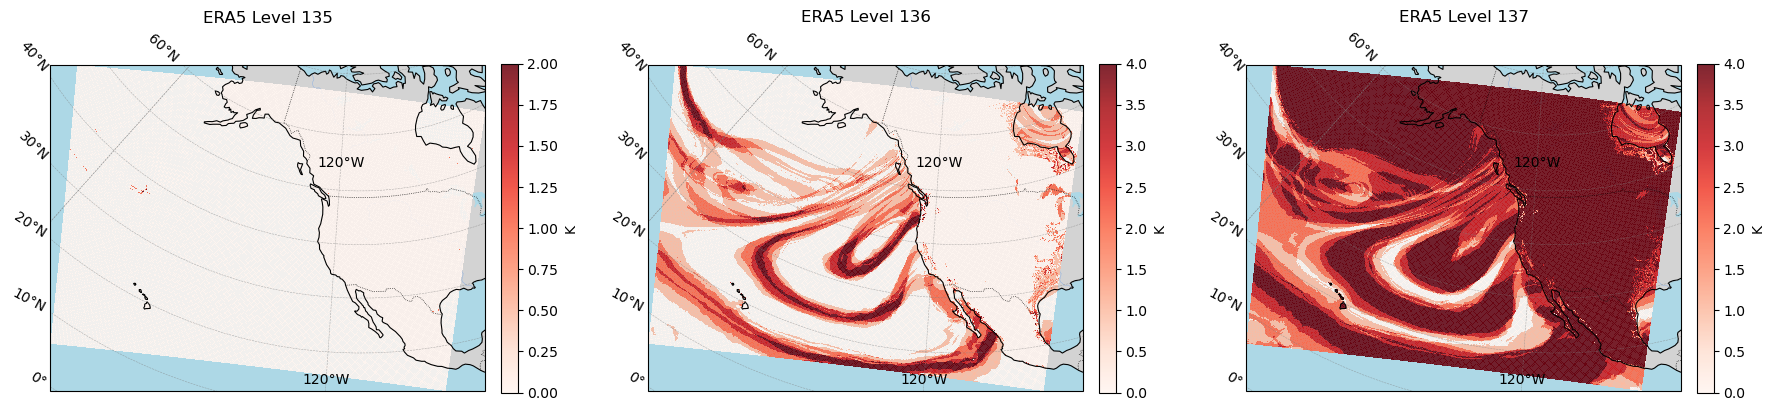

In [18]:
proj = ccrs.LambertConformal(
    central_longitude=float(lon2d.mean()),
    central_latitude=float(lat2d.mean())
)

fig, axes = plt.subplots(
    1, 3, figsize=(18, 5),
    subplot_kw={'projection': proj}
)

fields = {
    '135': field_135,
    '136': field_136,
    '137': field_137
}

for ax, (var, field) in zip(axes.flat, fields.items()):
    plot_on_map(field, lat2d, lon2d, title=f'ERA5 Level {var}', unit='K', cmap='Reds', ax=ax)

# fig.suptitle('Resampled Fields — η level 0, t=0', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

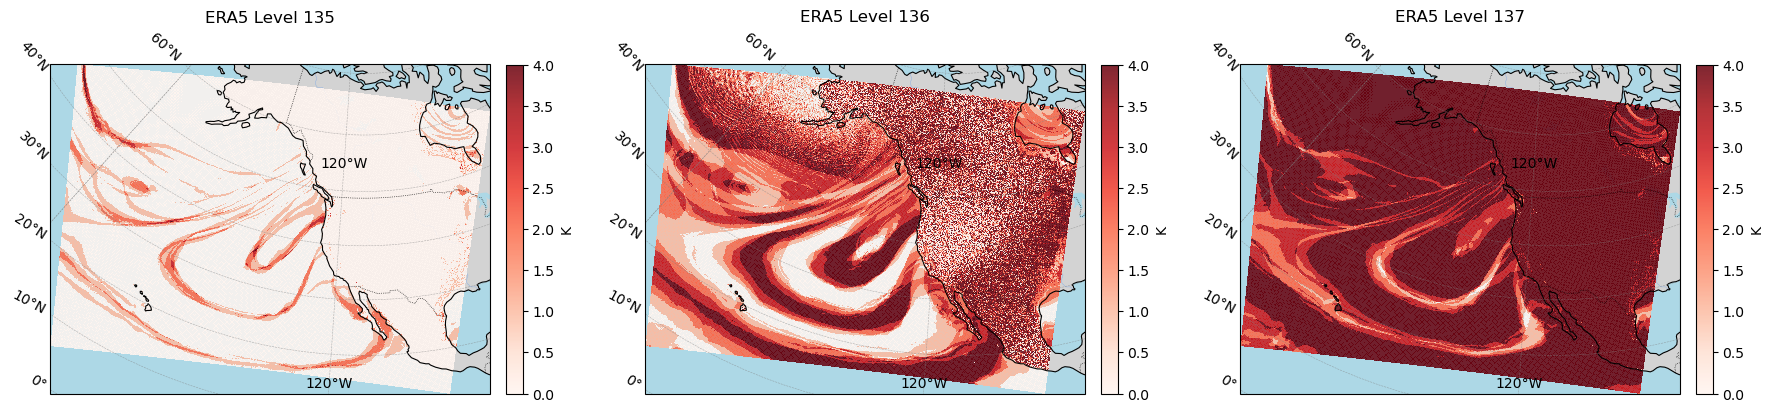

In [49]:
proj = ccrs.LambertConformal(
    central_longitude=float(lon2d.mean()),
    central_latitude=float(lat2d.mean())
)

fig, axes = plt.subplots(
    1, 3, figsize=(18, 5),
    subplot_kw={'projection': proj}
)

fields = {
    '135': field_135,
    '136': field_136,
    '137': field_137
}

for ax, (var, field) in zip(axes.flat, fields.items()):
    plot_on_map(field, lat2d, lon2d, title=f'ERA5 Level {var}', unit='K', cmap='Reds', ax=ax)

# fig.suptitle('Resampled Fields — η level 0, t=0', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

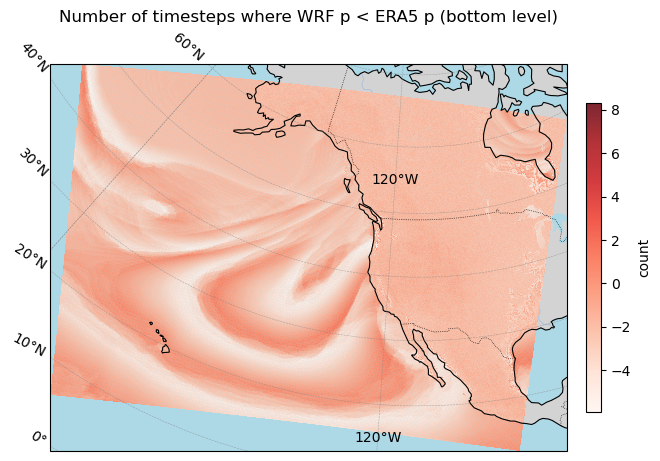

In [64]:
wrf_bot  = ds_resampled['p_e'].isel(eta=0)
era5_bot = p_era5.sel(level=137)

lat2d = ds_resampled['lat'].values
lon2d = ds_resampled['lon'].values

# Count how many timesteps WRF pressure < ERA5 pressure, per grid cell
# field = (wrf_bot - era5_bot < 0).sum(dim='time').compute()
field = (wrf_bot - era5_bot).mean(dim='time').compute()

plot_on_map(
    field, lat2d, lon2d,
    title='Number of timesteps where WRF p < ERA5 p (bottom level)',
    unit='count',
    cmap='Reds'
)
plt.tight_layout()
plt.show()

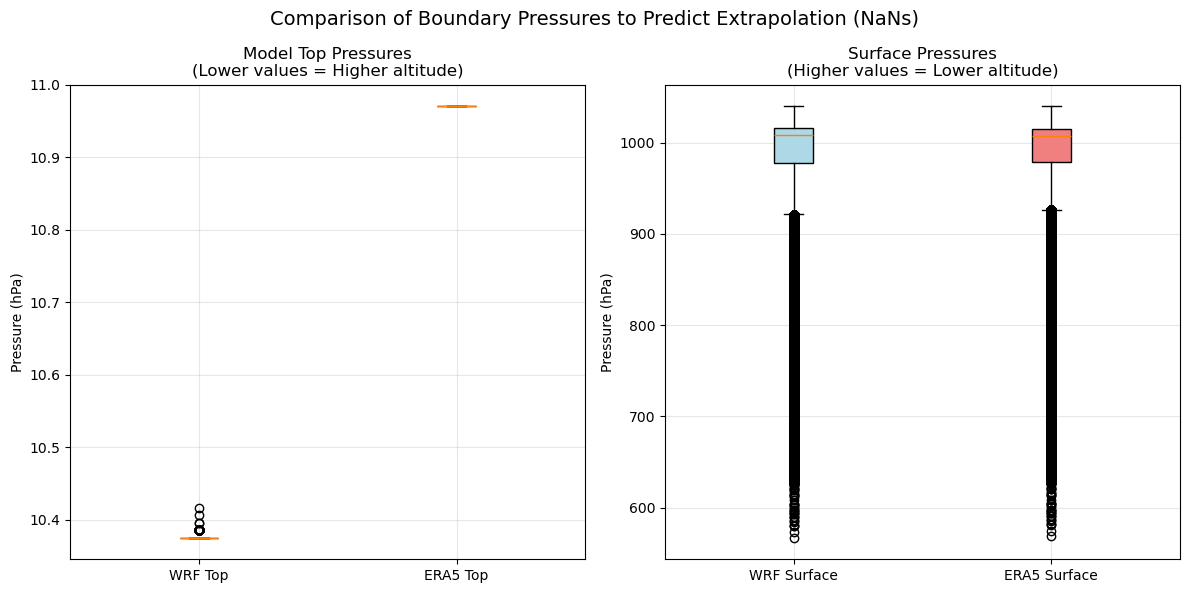

In [19]:
# Minimum pressure represents the Top of the Atmosphere
wrf_top = ds_resampled['p_e'].min(dim='eta').compute().values.flatten()
era5_top = p_era5.min(dim='level').compute().values.flatten()

# Maximum pressure represents the Surface
wrf_bot = ds_resampled['p_e'].max(dim='eta').compute().values.flatten()
era5_bot = p_era5.max(dim='level').compute().values.flatten()

# Remove any stray NaNs to ensure Matplotlib doesn't throw an error
wrf_top = wrf_top[~np.isnan(wrf_top)]
era5_top = era5_top[~np.isnan(era5_top)]
wrf_bot = wrf_bot[~np.isnan(wrf_bot)]
era5_bot = era5_bot[~np.isnan(era5_bot)]

# 2. Setup the figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# 3. Plot Model Top Pressures (Low Pressures)
bp1 = ax1.boxplot([wrf_top, era5_top], tick_labels=['WRF Top', 'ERA5 Top'], patch_artist=True)
ax1.set_title('Model Top Pressures\n(Lower values = Higher altitude)')
ax1.set_ylabel('Pressure (hPa)')
ax1.grid(True, alpha=0.3)

# 4. Plot Surface Pressures (High Pressures)
bp2 = ax2.boxplot([wrf_bot, era5_bot], tick_labels=['WRF Surface', 'ERA5 Surface'], patch_artist=True)
ax2.set_title('Surface Pressures\n(Higher values = Lower altitude)')
ax2.set_ylabel('Pressure (hPa)')
ax2.grid(True, alpha=0.3)

# 5. Color the boxes for clarity (Blue for WRF, Red for ERA5)
colors = ['lightblue', 'lightcoral']
for bplot in (bp1, bp2):
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)

plt.suptitle('Comparison of Boundary Pressures to Predict Extrapolation (NaNs)', fontsize=14)
plt.tight_layout()
plt.show()

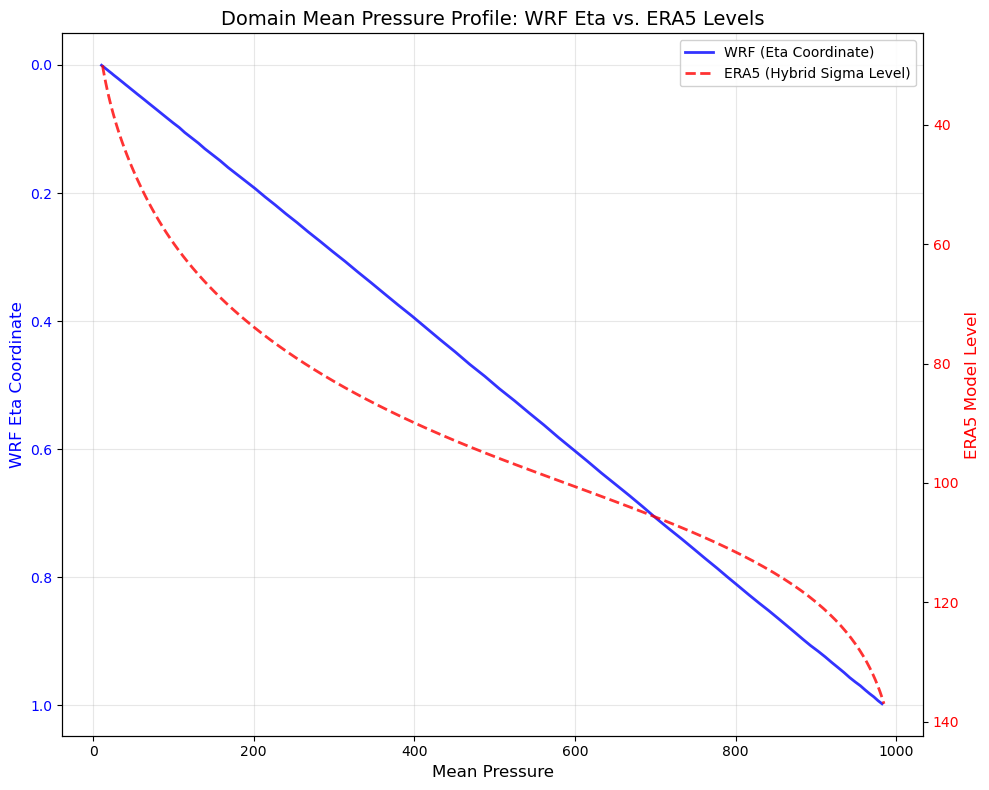

In [14]:
import matplotlib.pyplot as plt

# 1. Calculate the spatial/temporal averages
ds_avg_wrf = ds_resampled['p_e'].mean(dim=("time", "south_north", "west_east"))
ds_avg_era5 = p_era5.mean(dim=("time", "south_north", "west_east"))

# 2. Setup the figure and primary axis
fig, ax1 = plt.subplots(figsize=(10, 8))

# 3. Plot WRF data on the primary y-axis (ax1)
# Note: yincrease=False puts the surface (eta=1.0) at the bottom
ds_avg_wrf.plot(
    y='eta', 
    ax=ax1, 
    yincrease=False, 
    label='WRF (Eta Coordinate)', 
    color='blue', 
    linewidth=2,
    alpha=0.8
)

# Set labels for primary axis
ax1.set_ylabel('WRF Eta Coordinate', color='blue', fontsize=12)
ax1.set_xlabel('Mean Pressure', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')

# 4. Create a twin y-axis sharing the same x-axis
ax2 = ax1.twinx()

# 5. Plot ERA5 data on the secondary y-axis (ax2)
# Note: yincrease=False puts the surface (level=137) at the bottom
ds_avg_era5.plot(
    y='level', 
    ax=ax2, 
    yincrease=False, 
    label='ERA5 (Hybrid Sigma Level)', 
    color='red', 
    linewidth=2,
    linestyle='--', 
    alpha=0.8
)

# Set labels for secondary axis
ax2.set_ylabel('ERA5 Model Level', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

# 6. Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right', framealpha=0.9)

# 7. Final formatting
plt.title('Domain Mean Pressure Profile: WRF Eta vs. ERA5 Levels', fontsize=14)
ax1.grid(True, alpha=0.3)
plt.tight_layout()

# Show the plot
plt.show()

In [20]:
def compare_vertical_profiles(ds_orig, ds_regrid, variables=None):
    """
    Plot and compare spatially and temporally averaged vertical profiles 
    from the original Eta dataset and the regridded ERA5-level dataset.
    """
    var_metadata = {
        'Z_e': ('Geopotential', 'm²/s²'),
        'T_e': ('Temperature', 'K'),
        'q_e': ('Specific humidity', 'kg/kg'),
        'u_gr_e': ('Zonal wind', 'm/s'),
        'v_gr_e': ('Meridional wind', 'm/s')
    }

    if variables is None:
        variables = list(var_metadata.keys())
        
    # WRF spatial and temporal dimensions to average over
    # Adjust these if your resampled dataset uses different names (e.g., 'latitude', 'longitude')
    avg_dims = ["time", "south_north", "west_east"]
    
    LABEL_SIZE = 12
    TICK_SIZE = 10
    TITLE_SIZE = 14
    
    n_vars = len(variables)
    n_cols = min(3, n_vars)  
    n_rows = int(np.ceil(n_vars / n_cols))
    
    fig, axes = plt.subplots(ncols=n_cols, nrows=n_rows, figsize=(6*n_cols, 5*n_rows), 
                             constrained_layout=True)
    
    if n_vars == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    

    print("Triggering Dask computation for all variables simultaneously...")
    # Slice only the variables you need, calculate the mean lazily, then .compute() forces Dask 
    # to execute the graph and return the final small 1D arrays into local memory.
    ds_orig_avg = ds_orig[variables].mean(dim=avg_dims).compute()
    ds_regrid_avg = ds_regrid[variables].mean(dim=avg_dims).compute()
    print("Computation complete. Generating plots...")

    for i, var in enumerate(variables):
        if var not in ds_orig.data_vars or var not in ds_regrid.data_vars:
            print(f"Skipping {var} - not found in both datasets.")
            continue
            
        ax1 = axes[i]
        # Create a twin Y-axis for the regridded dataset
        ax2 = ax1.twinx() 
        
        var_orig_avg = ds_orig_avg[var]
        var_regrid_avg = ds_regrid_avg[var]

        nice_name, units = var_metadata.get(var, (var, ''))
        
        # 3. Plot Original Grid on primary Y-axis (ax1)
        line1 = ax1.plot(var_orig_avg, var_orig_avg['eta'], 
                         label='WRF Native (Eta)', color='blue', linewidth=2)
        
        # 4. Plot Regridded Grid on secondary Y-axis (ax2)
        line2 = ax2.plot(var_regrid_avg, var_regrid_avg['level'], 
                         label='Regridded (ERA5 Levels)', color='red', linewidth=2, linestyle='--')
        
        # Formatting primary axis (Eta)
        if units:
            ax1.set_xlabel(f'{nice_name} ({units})', fontsize=LABEL_SIZE)
        ax1.set_ylabel('WRF Eta Coordinate', fontsize=LABEL_SIZE, color='blue')
        ax1.tick_params(axis='y', labelcolor='blue', labelsize=TICK_SIZE)
        
        # Formatting secondary axis (ERA5 Level)
        ax2.set_ylabel('ERA5 Hybrid Level', fontsize=LABEL_SIZE, color='red')
        ax2.tick_params(axis='y', labelcolor='red', labelsize=TICK_SIZE)
        
        # Invert axes so ground is at the bottom (Eta 1 -> 0, Level 137 -> 1)
        ax1.invert_yaxis()
        ax2.invert_yaxis()
        
        ax1.set_title(f'Mean Vertical Profile: {nice_name}', fontsize=TITLE_SIZE)
        ax1.tick_params(axis='x', labelsize=TICK_SIZE)
        ax1.grid(True, alpha=0.3)

        # Handle Scientific Notation for Geopotential
        if var == 'Z_e':
            ax1.ticklabel_format(style='sci', axis='x', scilimits=(3, 3), useMathText=True)
            
        # Combine legends from both axes
        lines = line1 + line2
        labels = [l.get_label() for l in lines]
        ax1.legend(lines, labels, loc='best')
    
    # Hide unused subplots
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    
    plt.show()

Triggering Dask computation for all variables simultaneously...


/home/moerfani/miniforge3/envs/vis/lib/python3.14/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/home/moerfani/miniforge3/envs/vis/lib/python3.14/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


Computation complete. Generating plots...


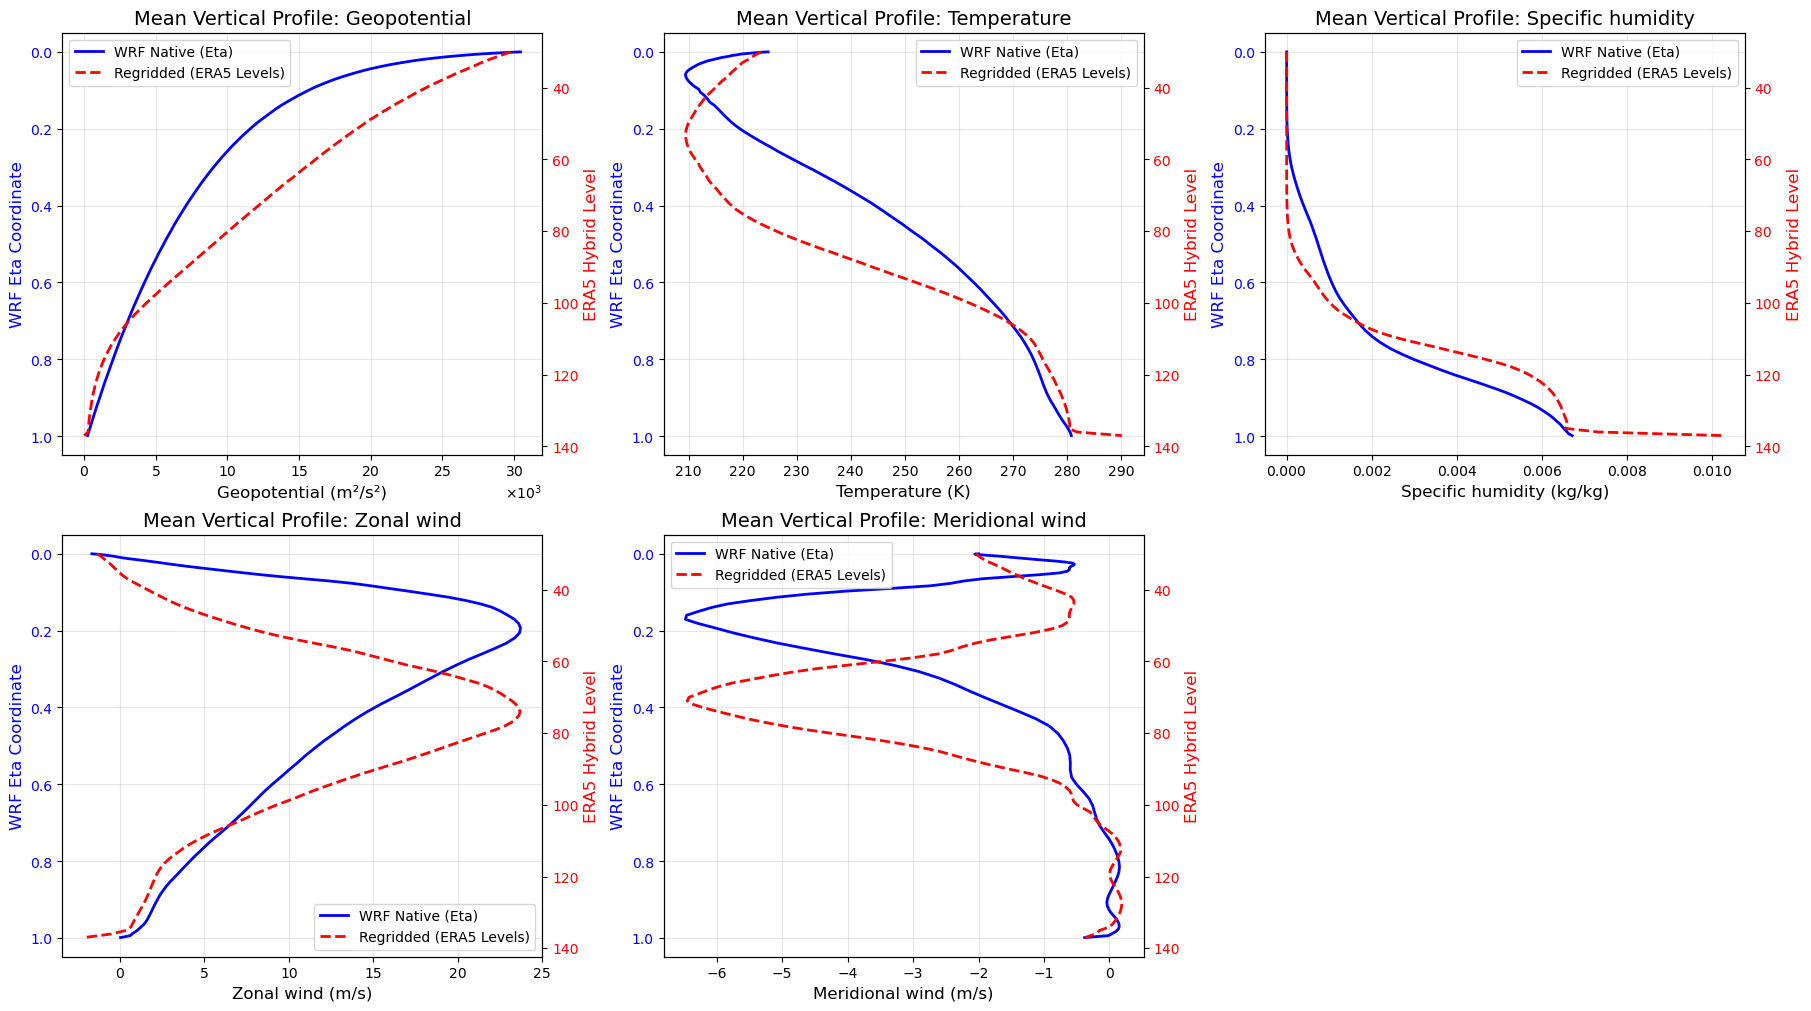

In [18]:
compare_vertical_profiles(ds_resampled, ds_era5_grid)

In [ ]:
import warnings
from xhistogram.xarray import histogram

# ---------------------------------------------------------
# 1. Define Variables and Bins
# ---------------------------------------------------------
variables = {
    'T_e':     ('Temperature',      'K'),
    'q_e':     ('Specific Humidity','kg/kg'),
    'u_gr_e':  ('Zonal Wind',       'm/s'),
    'v_gr_e':  ('Meridional Wind',  'm/s'),
}

z_max_era5      = ds_era5_grid['Z_e'].max().compute().item()
z_max_resampled = ds_resampled['Z_e'].max().compute().item()
absolute_max_z  = max(z_max_era5, z_max_resampled)

bin_size = 1000
bins = np.unique(np.arange(0, absolute_max_z + bin_size, bin_size).round(6))

dims_era5 = ["time", "level",  "south_north", "west_east"]
dims_wwrf = ["time", "eta",    "south_north", "west_east"]

# Pre-compute denominators once (same for all variables)
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=RuntimeWarning, module="scipy")

    denom_era5 = histogram(
        ds_era5_grid['Z_e'], bins=[bins], dim=dims_era5, block_size=None
    ).compute()

    denom_resampled = histogram(
        ds_resampled['Z_e'], bins=[bins], dim=dims_wwrf, block_size=None
    ).compute()

# ---------------------------------------------------------
# 2. Loop Over Variables → Compute Profiles
# ---------------------------------------------------------
profiles = {}   # profiles[var] = (profile_era5, profile_resampled)

for var in variables:
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=RuntimeWarning, module="scipy")

        num_era5 = histogram(
            ds_era5_grid['Z_e'],
            bins=[bins],
            dim=dims_era5,
            weights=ds_era5_grid[var],
            block_size=None,
        ).compute()                                         # <-- compute() INSIDE block

        num_resampled = histogram(
            ds_resampled['Z_e'],
            bins=[bins],
            dim=dims_wwrf,
            weights=ds_resampled[var],
            block_size=None,
        ).compute()                                         # <-- compute() INSIDE block

    profile_era5      = xr.where(denom_era5      > 0, num_era5      / denom_era5,      np.nan)
    profile_resampled = xr.where(denom_resampled > 0, num_resampled / denom_resampled, np.nan)

    profiles[var] = (profile_era5, profile_resampled)

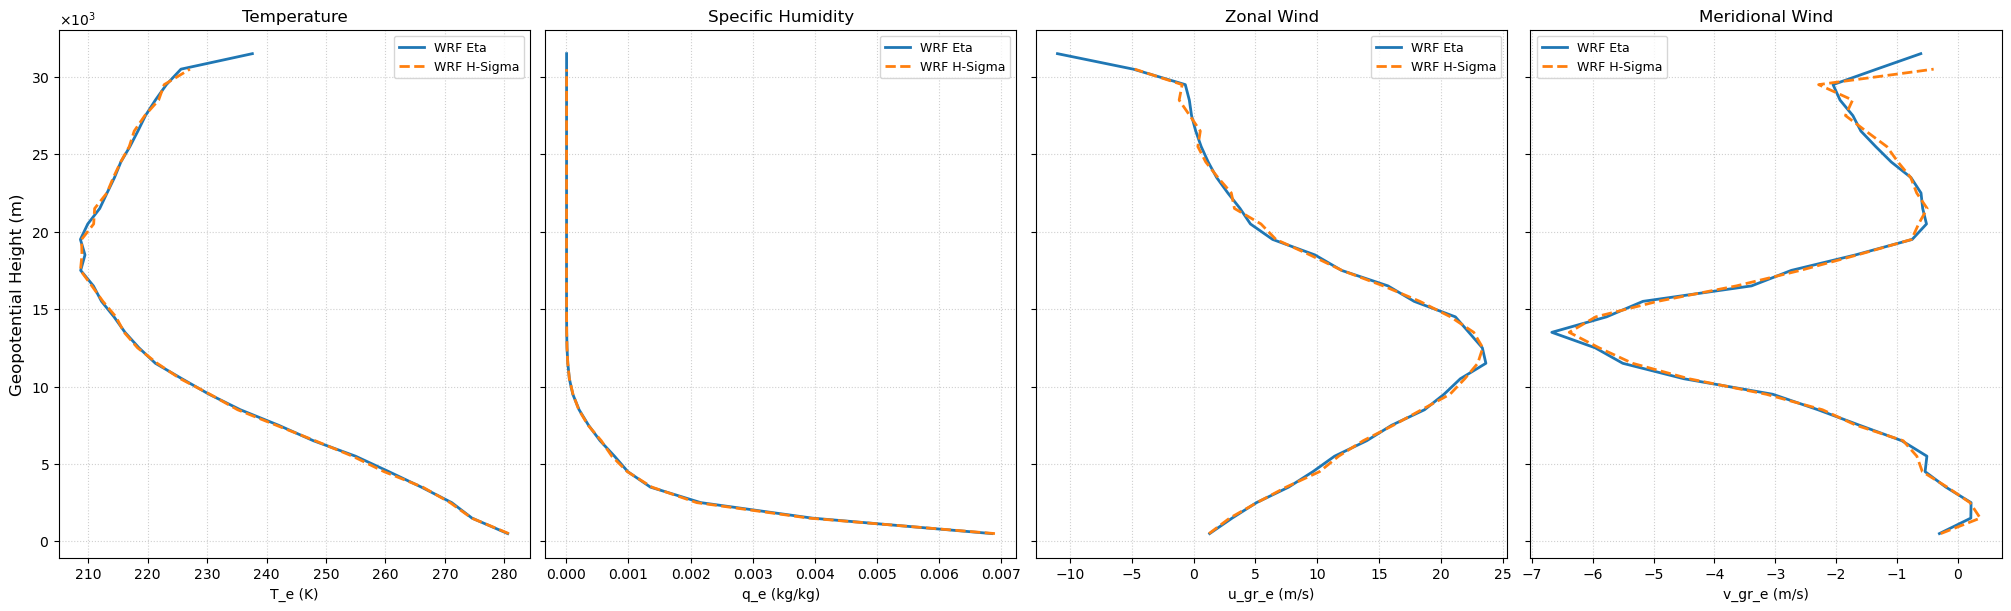

In [22]:
n_vars = len(variables)
fig, axes = plt.subplots(1, n_vars, figsize=(5 * n_vars, 6), constrained_layout=True, sharey=True)

z_bins = profile_era5['Z_e_bin']  # shared coordinate

for ax, (var, (prof_era5, prof_resampled)) in zip(axes, profiles.items()):
    long_name, unit = variables[var]

    
    ax.plot(prof_resampled, z_bins, label='WRF Eta',  linewidth=2)
    ax.plot(prof_era5,      z_bins, label='WRF H-Sigma',  linewidth=2, linestyle='--')

    ax.set_title(long_name, fontsize=12)
    ax.ticklabel_format(style='sci', axis='y', scilimits=(3, 3), useMathText=True)
    ax.set_xlabel(f'{var} ({unit})', fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(fontsize=9)

axes[0].set_ylabel('Geopotential Height (m)', fontsize=12)

# fig.suptitle('Average Vertical Profiles: ERA5 vs Resampled', fontsize=14, y=1.01)

plt.show()

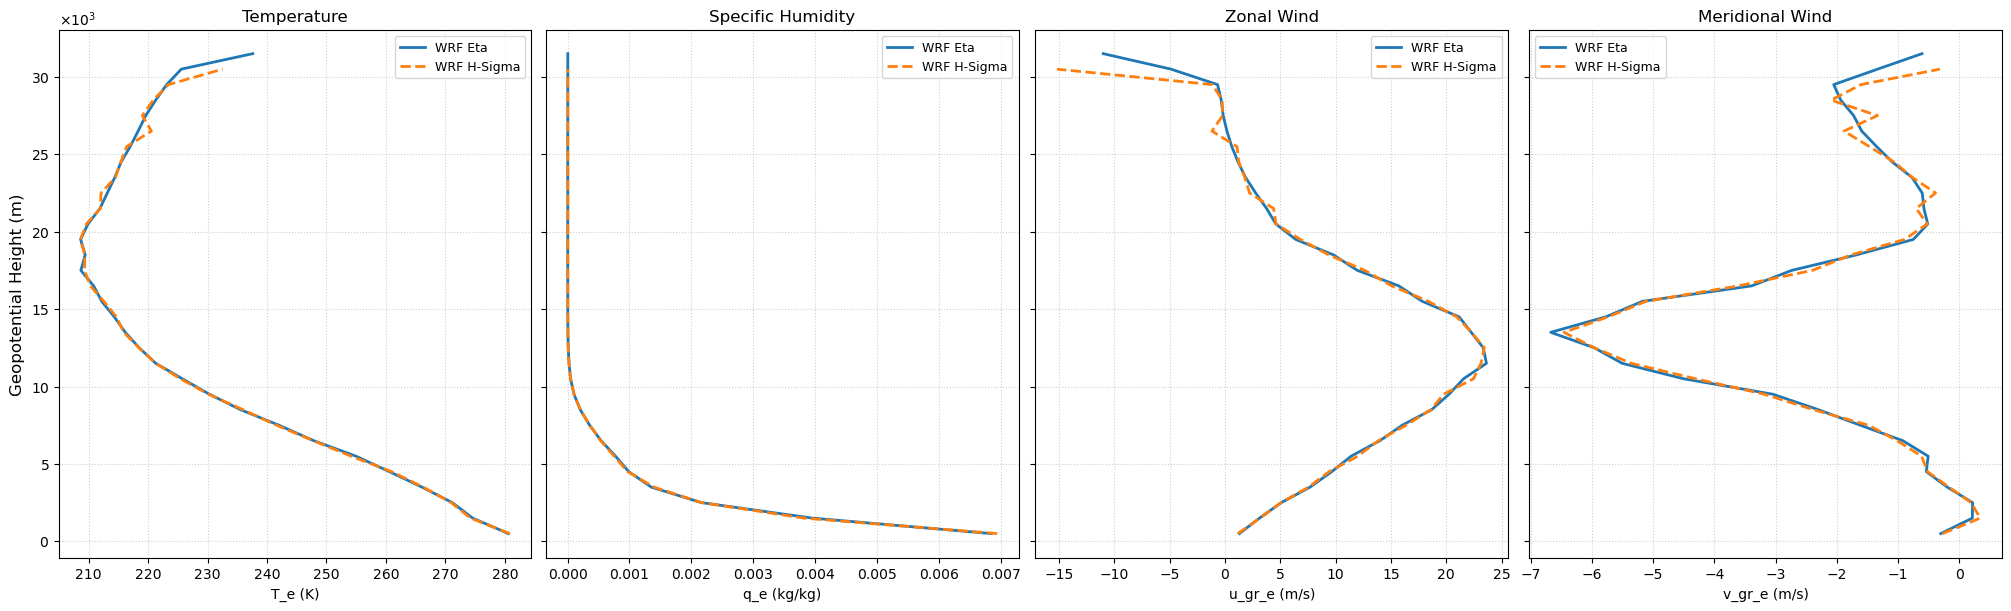

In [24]:
n_vars = len(variables)
fig, axes = plt.subplots(1, n_vars, figsize=(5 * n_vars, 6), constrained_layout=True, sharey=True)

z_bins = profile_era5['Z_e_bin']  # shared coordinate

for ax, (var, (prof_era5, prof_resampled)) in zip(axes, profiles.items()):
    long_name, unit = variables[var]

    
    ax.plot(prof_resampled, z_bins, label='WRF Eta',  linewidth=2)
    ax.plot(prof_era5,      z_bins, label='WRF H-Sigma',  linewidth=2, linestyle='--')

    ax.set_title(long_name, fontsize=12)
    ax.ticklabel_format(style='sci', axis='y', scilimits=(3, 3), useMathText=True)
    ax.set_xlabel(f'{var} ({unit})', fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(fontsize=9)

axes[0].set_ylabel('Geopotential Height (m)', fontsize=12)

# fig.suptitle('Average Vertical Profiles: ERA5 vs Resampled', fontsize=14, y=1.01)

plt.show()